In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

pd.options.display.float_format = '{:.2f}'.format

In [ ]:
qSales = pd.read_csv('qSales_2024.csv')

#Make sure the date column is recognized as a date, important for time series regression
qSales['datadate'] = pd.to_datetime(qSales['datadate'])

#Filter down to Target only
target_sales = qSales.loc[qSales['tic'] == 'TGT'].copy()
target_sales = target_sales.sort_values('datadate').reset_index(drop=True)

display(target_sales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat
0,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.00,A
1,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.00,A
2,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.00,A
3,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.00,A
4,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.00,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.00,A
89,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.00,A
90,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,24773.00,A
91,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.00,A


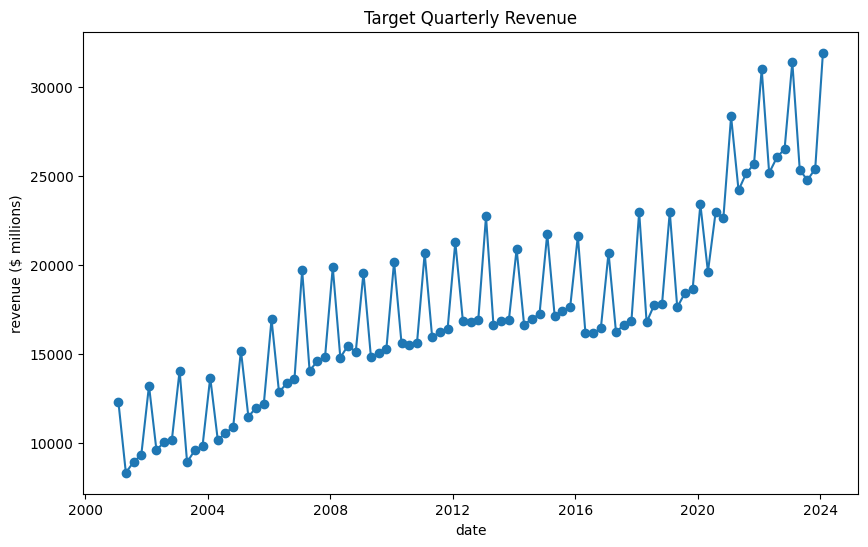

In [ ]:
plt.figure(figsize=(10,6))

plt.title('Target Quarterly Revenue')
plt.xlabel('date')
plt.ylabel('revenue ($ millions)')

plt.plot(target_sales['datadate'], target_sales['saleq'], marker='o')
plt.show()

In [ ]:
#Time period counter, same convention as class: 1, 2, 3...
target_sales['time'] = range(1, len(target_sales) + 1)

display(target_sales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time
0,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.00,A,1
1,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.00,A,2
2,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.00,A,3
3,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.00,A,4
4,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.00,A,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.00,A,89
89,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.00,A,90
90,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,24773.00,A,91
91,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.00,A,92


In [ ]:
#Dummy variable 1: Holiday quarter (fiscal Q4, which covers Nov to Jan)
target_sales['holiday_q4'] = np.where(target_sales['fqtr'] == 4, 1, 0)

#Dummy variable 2:COVID 19 demand surge period (Q2 2020 onward)
target_sales['covid_surge'] = np.where(target_sales['datadate'] >= '2020-04-01', 1, 0)

display(target_sales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time,holiday_q4,covid_surge
0,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.00,A,1,1,0
1,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.00,A,2,0,0
2,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.00,A,3,0,0
3,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.00,A,4,0,0
4,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.00,A,5,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.00,A,89,1,1
89,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.00,A,90,0,1
90,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,24773.00,A,91,0,1
91,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.00,A,92,0,1


In [ ]:
x = target_sales.loc[:, ['time', 'holiday_q4', 'covid_surge']]
x = sm.add_constant(x)

y = target_sales.loc[:, 'saleq']

model_target = sm.OLS(y, x).fit()

model_target.params

,0
const,9447.95
time,130.01
holiday_q4,4835.37
covid_surge,4233.24


## To: Chapman Wealth Management
## From: QuantFolio Solutions
## Date: July 24, 2026
## Re: Target Corporation Quarterly Revenue Model, Investment Due Diligence


Target's revenue looks highly predictable and is getting structurally stronger over time, which supports staying confident in the investment thesis.

Problem and decision. Chapman wants a data backed read on how stable and forecastable Target's revenue really is before sizing a position in the stock.

Scope and unit of analysis. We used 23 years of quarterly revenue, fiscal Q4 2000 through Q4 2023, sourced from Compustat with no missing values. The unit of analysis is the fiscal quarter.

Methodology. We built a regression in Python with pandas and statsmodels, regressing revenue on a time trend plus two dummy variables pulled from the clearest patterns in the data: a holiday quarter flag for fiscal Q4 (November through January) and a COVID era flag covering Q2 2020 onward.

Key findings. The model explains about 94.6% of the variation in Target's quarterly revenue, and every variable is statistically significant. Fiscal Q4 runs roughly 4.8 billion above a normal quarter, and that holds in every single year of the sample. The COVID era added another 4.2 billion or so on top of the pre 2020 trend, and that elevated level has stuck rather than fading, pointing to a durable gain rather than a temporary spike. Underlying organic growth runs around 130 million per quarter.

Recommendation. Move forward with confidence in Target's revenue durability, but rerun this model each quarter, holding out the most recent 25% of data to test it out of sample, to confirm the elevated post pandemic base and growth rate are still holding before finalizing position sizing.